# The code, start to finish

Only the code that produces the results, in the order it runs. Every listing is printed from the
repo files (`src/hemo/`, `experiments/`), so it is exactly what ran. After each listing, a cell runs
it on a small version of the task (8 slots, 2 distances, 8 heads) so you can see what it produces.

| step | what | file |
|---|---|---|
| 1 | the settings | `src/hemo/config.py` |
| 2 | the task | `src/hemo/tasks.py` |
| 3 | the model | `src/hemo/model.py`, `CrossAttn` |
| 4 | the valves and the collateral rule | `src/hemo/model.py`, `HemoAttn` |
| 5 | training | `src/hemo/train.py` |
| 6 | one experiment | `experiments/run.py` |
| 7 | the results | `results/`, `figures/` |

For the same steps explained slowly and by hand, see `walkthrough_by_hand.ipynb` and `hmha_by_hand.xlsx`.

In [1]:
import glob, inspect, pickle, sys, textwrap
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Image, display
from dataclasses import replace

sys.path.insert(0, "../src")
from hemo.config import Cfg
from hemo.tasks import make_batch, make_val, offsets_for, trivial_loss
from hemo.model import CrossAttn, HemoAttn
from hemo.train import train
torch.set_num_threads(4)


def _cut(lines, start=None, end=None):
    if start:
        lines = lines[next(i for i, l in enumerate(lines) if start in l):]
    if end:
        lines = lines[:next(i for i, l in enumerate(lines) if end in l) + 1]
    out, inside = [], False
    for l in lines:                                   # leave docstrings out
        t = l.strip()
        if not inside and t.startswith('\"\"\"'):
            inside = not (t.endswith('\"\"\"') and len(t) > 3)
            continue
        if inside:
            inside = not t.endswith('\"\"\"')
            continue
        out.append(l)
    print(textwrap.dedent("\n".join(out)))


def show(obj, start=None, end=None):                # print a function or class from the repo
    _cut(inspect.getsource(obj).splitlines(), start, end)


def show_file(path, start=None, end=None):          # print part of a file from the repo
    _cut(open(path, encoding="utf-8").read().splitlines(), start, end)


SMALL = replace(Cfg(), seq_len=8, n_rel=2, m_content=4, d_model=16, num_heads=8, d_k=8,
                steps=2000, batch_size=128, val_size=512, val_every=100, device="cpu", seed=0)
print("ready")

ready


## 1. The settings (`src/hemo/config.py`)

One settings object, `Cfg`, holds every number. These are the lines this project uses (the file
also holds settings for older rules that are switched off). `SMALL` above is a copy with smaller numbers.

The values printed are the file's **defaults**. The collateral-rule experiments override five of them
on the command line (step 6): `supply=local` (the collateral rule), `price_frac=0.03`, `taper=100`,
`budget_hold_frac=0.1` (first decision after 10% of training) and `conserve=0`.

In [2]:
used = ("d_model:", "seq_len:", "n_rel:", "m_content:", "num_heads:", "d_k:", "supply:", "price_frac:",
        "probe_every:", "probe_batch:", "taper:", "budget_hold_frac:", "conserve:", "local_value:",
        "batch_size:", "steps:", "lr:", "seed:")
for line in inspect.getsource(Cfg).splitlines():
    if line.strip().startswith(used):
        print(line.strip())

d_model: int = 128
seq_len: int = 16                   # N
n_rel: int = 4                      # R. Ground-truth k* for multi_relation.
m_content: int = 16
num_heads: int = 32
d_k: int = 32
supply: str = "threshold"
price_frac: float = 0.01            # local only. Price of one head, as a fraction of
probe_every: int = 25               # local and prune. Steps between decisions.
taper: int = 0                      # local only. Steps over which a closing head's
probe_batch: int = 512              # local only. Fresh sequences per probe, so the
conserve: int = 1                   # local only. 0 = CONTROL: no fixed total, an open
local_value: str = "refit"          # local only. Which head to close:
budget_hold_frac: float = 0.25
batch_size: int = 128
steps: int = 4000
lr: float = 2e-3
seed: int = 0


In [3]:
for name in ("seq_len", "n_rel", "m_content", "d_model", "num_heads", "d_k", "steps"):
    print(f"{name:<10} SMALL {getattr(SMALL, name):>5}   real {getattr(Cfg(), name):>5}")

seq_len    SMALL     8   real    16
n_rel      SMALL     2   real     4
m_content  SMALL     4   real    16
d_model    SMALL    16   real   128
num_heads  SMALL     8   real    32
d_k        SMALL     8   real    32
steps      SMALL  2000   real  4000


## 2. The task (`src/hemo/tasks.py`)

Memory `Y`: one row per slot, `[one-hot label | random item | noise]`. Queries `X`: one row per query,
`[one-hot of p | noise]`. Target `T`: the items at `(p + offset) mod N`, side by side.

In [4]:
show(offsets_for)
show(make_batch, 'elif cfg.task == "multi_relation"', 'aux = {"p": p')
show(make_val)
show(trivial_loss)

def offsets_for(cfg):
    return [(1 + r * max(1, cfg.seq_len // cfg.n_rel)) % cfg.seq_len for r in range(cfg.n_rel)]
elif cfg.task == "multi_relation":
    m = cfg.m_content
    assert d >= N + m, "d_model must hold the position block plus the content block"
    X = torch.randn(B, N, d, device=dev, **kw) * 0.1
    Y = torch.randn(B, N, d, device=dev, **kw) * 0.1
    Y[:, :, :N] = torch.eye(N, device=dev)
    content = torch.randn(B, N, m, device=dev, **kw)
    Y[:, :, N:N + m] = content
    p = torch.randint(0, N, (B, N), device=dev, **kw)
    X[:, :, :N] = F.one_hot(p, N).float()
    blocks = []
    for off in offsets_for(cfg):
        j = (p + off) % N
        blocks.append(torch.gather(content, 1, j.unsqueeze(-1).expand(-1, -1, m)))
    T = torch.cat(blocks, dim=-1)
    aux = {"p": p, "offsets": torch.tensor(offsets_for(cfg), device=dev)}
def make_val(cfg, device, seed=10_000):
    return make_batch(cfg.val_size, cfg, device, gen=torch.Generator().manual_seed(seed))
def trivial_los

In [5]:
X, Y, T, aux = make_batch(2, SMALL, "cpu", gen=torch.Generator().manual_seed(0))
print("X", tuple(X.shape), " Y", tuple(Y.shape), " T", tuple(T.shape), "  offsets", offsets_for(SMALL))
N, m = SMALL.seq_len, SMALL.m_content
p0 = int(aux["p"][0, 0])
for r, off in enumerate(offsets_for(SMALL)):        # check one answer by hand
    j = (p0 + off) % N
    print(f"query 0: p = {p0}, ({p0} + {off}) mod {N} = {j}, target block {r} = item in slot {j}:",
          torch.equal(T[0, 0, r * m:(r + 1) * m], Y[0, j, N:N + m]))

X (2, 8, 16)  Y (2, 8, 16)  T (2, 8, 8)   offsets [1, 5]
query 0: p = 1, (1 + 1) mod 8 = 2, target block 0 = item in slot 2: True
query 0: p = 1, (1 + 5) mod 8 = 6, target block 1 = item in slot 6: True


## 3. The model (`src/hemo/model.py`, `CrossAttn`)

One cross-attention layer, no MLP. All heads' weights are stored together and cut into heads by
`_split`. `heads` computes every head's blend; `combine` multiplies each head's blend by its valve
(`out * gate`) and applies the output weights.

In [6]:
show(CrossAttn)

class CrossAttn(nn.Module):
    def __init__(self, cfg, num_heads=None):
        super().__init__()
        self.cfg = cfg
        self.H = num_heads or cfg.num_heads
        self.d_k, self.d_model = cfg.d_k, cfg.d_model
        self.d_out = d_out(cfg)
        inner = self.H * self.d_k
        self.W_q = nn.Linear(cfg.d_model, inner)
        self.W_k = nn.Linear(cfg.d_model, inner)
        self.W_v = nn.Linear(cfg.d_model, inner)
        self.W_o = nn.Linear(inner, self.d_out)

    def _split(self, x):
        B, N, _ = x.shape
        return x.view(B, N, self.H, self.d_k).transpose(1, 2)

    def heads(self, X, Y, attn_override=None):
        Q, K, V = self._split(self.W_q(X)), self._split(self.W_k(Y)), self._split(self.W_v(Y))
        if attn_override is None:
            attn = F.softmax(Q @ K.transpose(-2, -1) / math.sqrt(self.d_k), dim=-1)
        else:
            attn = attn_override.unsqueeze(1).expand(-1, self.H, -1, -1)
        return Q, attn, attn @ V

    def combine(self, 

In [7]:
torch.manual_seed(0)
layer = CrossAttn(SMALL)
Q, attn, out = layer.heads(X, Y)
pred, g = layer(X, Y)
print("Q", tuple(Q.shape), " attention", tuple(attn.shape), " each head's blend", tuple(out.shape),
      " prediction", tuple(pred.shape), " valves", tuple(g.shape))

Q (2, 8, 8, 8)  attention (2, 8, 8, 8)  each head's blend (2, 8, 8, 8)  prediction (2, 8, 8)  valves (2, 8)


## 4. The valves and the collateral rule (`src/hemo/model.py`, `HemoAttn`)

`HemoAttn` is `CrossAttn` with valves controlled by a rule. With `supply="local"` (the collateral rule):
- `gate`: each head's valve is its tone, 1 = open, 0 = closed, in between while fading;
- `probe_ischemia`: each head's collateral value, the loss rise if it is removed and the other heads
  re-fit the output weights (one matrix inverse, then a small correction per head);
- `local_step`: close the cheapest head if it is worth less than the price; reopen a closed head
  worth more than twice the price;
- `relax_tone`: move each valve toward open or closed by 1/taper per step.

In [8]:
show(HemoAttn.forward)
show(HemoAttn.gate, 'if self.supply_kind == "local"', "return self.H * self.tone")

def forward(self, X, Y, kappa=None, B_active=None, gate=None,
            attn_override=None, update=True):
    Q, attn, out = self.heads(X, Y, attn_override)
    if gate is None:
        if update and self.training:
            self.update_demand(Q, attn, out)
        gate = self.gate(kappa=kappa, B_active=B_active)
    if gate.dim() == 1:
        if self.needs_gate_grad() and torch.is_grad_enabled():
            # a differentiable leaf, so dL/dg_h can be read after backward. The
            # gradient is well defined even where g_h == 0, which is what lets a
            # STARVED head still report the flow it would have used.
            gate = gate.detach().requires_grad_(True)
            self._gate_leaf = gate
        gate = gate.unsqueeze(0).expand(X.size(0), -1)
    used = gate
    if self.head_dropout > 0 and self.training:
        # DAMAGE: every head fails independently this step. The returned gate is the
        # allocation (what the ledger records); only the computation se

In [9]:
show(HemoAttn.probe_ischemia, "H, dk = self.H", "self.head_value.copy_(value")

H, dk = self.H, self.d_k
_, _, out = self.heads(X, Y)                                  # (b, H, n, dk)
Z = out.permute(0, 2, 1, 3).reshape(-1, H * dk).double()
t = T.reshape(-1, T.size(-1)).double()
Z, t = Z - Z.mean(0), t - t.mean(0)
n, d_out = Z.size(0), t.size(1)
A, Bm = Z.T @ Z / n, Z.T @ t / n
A += ridge * torch.diagonal(A).mean() * torch.eye(H * dk, dtype=A.dtype, device=A.device)

open_ = self.open_mask
blk = torch.arange(H * dk, device=Z.device).view(H, dk)
if self.head_dropout > 0:
    self._probe_under_damage(A, Bm, blk, d_out)
    return
S = blk[open_].reshape(-1)
M = torch.linalg.inv(A[S][:, S])
W = M @ Bm[S]                                                 # re-fitted read-out
value = torch.zeros(H, dtype=A.dtype, device=A.device)

ablate = torch.zeros(H, dtype=A.dtype, device=A.device)
heads_open = torch.nonzero(open_).flatten()
for i, h in enumerate(heads_open.tolist()):                  # fit lost without h
    J = slice(i * dk, (i + 1) * dk)
    value[h] = torch.trace(W

In [10]:
show(HemoAttn.local_step)
show(HemoAttn.relax_tone)

@torch.no_grad()
def local_step(self, price):
    v, open_ = self.head_value, self.open_mask
    if int(open_.sum()) > 1:
        # the controls change only WHICH value decides the closure (reopening below is
        # always the re-fit gain): ablate swaps in the standard score, random keeps the
        # rule's timing but picks the head blind
        score = self.head_ablate if self.local_value == "ablate" else v
        cheapest = torch.where(open_, score, torch.full_like(score, float("inf")))
        h = int(cheapest.argmin())
        if float(cheapest[h]) < price:
            if self.local_value == "random":
                idx = torch.nonzero(open_).flatten().cpu()
                h = int(idx[torch.randint(len(idx), (1,), generator=self._pick)])
            open_[h] = False
            return
    best = torch.where(~open_, v, torch.full_like(v, -float("inf")))
    h = int(best.argmax())
    if float(best[h]) > 2 * price:
        open_[h] = True
@torch.no_grad()
def relax_tone(self

## 5. Training (`src/hemo/train.py`)

The training loop with the lines the collateral rule uses: every step, a fresh batch, a forward pass,
a gradient step, and the valves move toward their targets; every 25 steps after the warm-up (`hold`),
value the heads and close or reopen one. (The full function also runs older rules and controls.)

In [11]:
keep = ("def train(", "model = (HemoAttn", "opt = torch.optim", "hold = int(", "local = hemo and",
        "price = cfg.price_frac", "for step in range(total)", "X, Y, T, _ = make_batch(cfg.batch_size",
        "pred, g = model(X, Y", "loss = F.mse_loss(pred, T)", "opt.zero_grad", "loss.backward()",
        "opt.step()", "if local:", "model.relax_tone()", "if (step - hold) % cfg.probe_every == 0",
        "model.probe_ischemia(*make_batch", "model.local_step(price)", 'h["ledger"].append(g[0]',
        'h["val_loss"].append(evaluate', "return model, h")
seen = set()
for line in inspect.getsource(train).splitlines():
    if any(k in line for k in keep) and line.strip() not in seen:
        seen.add(line.strip())
        print(line)

def train(cfg, val, device, hemo=True, num_heads=None, steps=None, desc="", verbose=False):
    model = (HemoAttn(cfg, num_heads) if hemo else CrossAttn(cfg, num_heads)).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    hold = int(cfg.budget_hold_frac * total)
    local = hemo and cfg.supply == "local"
    price = cfg.price_frac * trivial_loss(val)
    for step in range(total):
        X, Y, T, _ = make_batch(cfg.batch_size, cfg, device)
            pred, g = model(X, Y, kappa=kappa,
            pred, g = model(X, Y)
        loss = F.mse_loss(pred, T)
        opt.zero_grad(set_to_none=True)
            loss.backward()
        opt.step()
        if local:
            model.relax_tone()
            if (step - hold) % cfg.probe_every == 0:
                            model.probe_ischemia(*make_batch(cfg.probe_batch, cfg, device)[:3])
                            model.local_step(price)
                elif local:
                h["led

## 6. One experiment (`experiments/run.py`)

Every result in `results/` is one call of this script, e.g.
`python experiments/run.py --n_rel 4 --seed 0 --supply local --price_frac 0.03 --taper 100 --budget_hold_frac 0.1 --conserve 0`.
It builds the settings from the command line, trains with the rule, and saves everything to a `.pkl`.

In [12]:
show_file("../experiments/run.py", "cfg = Cfg()", 'out["final_loss"]')

cfg = Cfg()
for k, v in vars(a).items():
    if v is not None and hasattr(cfg, k):
        cfg = replace(cfg, **{k: v})
device = pick_device(cfg)
print(f"device {device}  task {cfg.task}  supply {cfg.supply}  demand {cfg.demand}  "
      f"seed {cfg.seed}  predicted k* {predicted_kstar(cfg)}")

val = make_val(cfg, device)
ks = k_list(cfg.num_heads, extra=(predicted_kstar(cfg),))
out = {"cfg": asdict(cfg), "trivial": trivial_loss(val), "ks": ks}
t0 = time.time()

if not a.skip_redundancy:
    print("  ground-truth k* (dense, k heads from scratch)")
    out["redundancy"] = redundancy_check(cfg, val, device, ks)

model, hist = train(cfg, val, device, hemo=True, desc="hemo", verbose=True)
out["hist"] = hist
out["final_loss"] = hist["val_loss"][-1]


The same thing, run here on the small task. First the dense model with 1 and 2 heads (the task needs
2), then the collateral rule starting from 8 heads, three seeds.

In [13]:
val = make_val(SMALL, "cpu")
triv = trivial_loss(val)
for H in (1, 2):
    _, hist = train(SMALL, val, "cpu", hemo=False, num_heads=H)
    print(f"dense, {H} head(s): final loss {hist['val_loss'][-1]:.4f}   (know-nothing loss {triv:.3f})")

dense, 1 head(s): final loss 0.4256   (know-nothing loss 0.987)


dense, 2 head(s): final loss 0.0007   (know-nothing loss 0.987)


collateral rule, seed 0: heads kept [0, 5] (2 of 8, task needs 2), final loss 0.0004


collateral rule, seed 1: heads kept [3, 6] (2 of 8, task needs 2), final loss 0.0003


collateral rule, seed 2: heads kept [2, 6] (2 of 8, task needs 2), final loss 0.0005


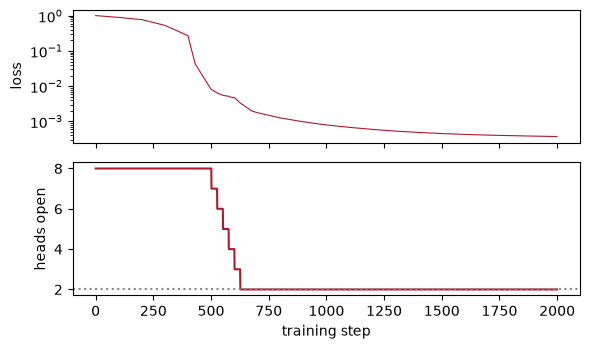

In [14]:
RULE_SMALL = replace(SMALL, supply="local", price_frac=0.03, taper=100, budget_hold_frac=0.2,
                     conserve=0, probe_batch=256)
runs = []
for seed in range(3):
    model, hist = train(replace(RULE_SMALL, seed=seed), val, "cpu", hemo=True)
    runs.append(hist)
    kept = (hist["ledger"][-1] > 0).nonzero()[0].tolist()
    print(f"collateral rule, seed {seed}: heads kept {kept} ({len(kept)} of 8, task needs 2), "
          f"final loss {hist['val_loss'][-1]:.4f}")

hist = runs[0]
fig, ax = plt.subplots(2, 1, figsize=(6, 3.6), sharex=True)
ax[0].semilogy(hist["val_step"], hist["val_loss"], color="#b2182b", lw=0.8); ax[0].set_ylabel("loss")
ax[1].plot((hist["ledger"] > 0).sum(1), color="#b2182b"); ax[1].axhline(2, color="#888", ls=":")
ax[1].set_ylabel("heads open"); ax[1].set_xlabel("training step")
plt.tight_layout(); plt.show()

## 7. The results of the full experiments

The saved runs (`results/`, 16 slots, 32 heads, 4000 steps), read back and counted. *Exact count*:
the heads kept equal the number the task needs. *Never broke*: once solved, the loss never went back
above the solved bar.

In [15]:
D = Cfg()
RUNS = [pickle.load(open(f, "rb")) for d in ("../results", "../results/proposal", "../results/confirm", "../results/l0")
        for f in glob.glob(d + "/*.pkl")]
RUNS = [r for r in RUNS if isinstance(r, dict) and "hist" in r and "ledger" in r.get("hist", {})]
PIN = dict(task="multi_relation", steps=4000, d_k=32, demand="outnorm_ema", leak=0.0, probe_every=25,
           prune_stop=1, conserve=1, local_value="refit", plant_copies=0, head_dropout=0.0,
           trial=0, target_frac=0.02, budget_hold_frac=0.25, taper=0, price_frac=0.01, l0_lambda=0.01)
get = lambda r, k: r["cfg"].get(k, getattr(D, k))
runs_of = lambda **w: [r for r in RUNS if all(get(r, k) == v for k, v in {**PIN, **w}.items())]
kept = lambda r: float(np.median(((r["hist"]["ledger"] > 0).sum(1))[int(0.6 * len(r["hist"]["ledger"])):]))


def never_broke(r):
    h, bar = r["hist"], 0.02 * r["trivial"]
    ls = [l for s, l in zip(h["val_step"], h["val_loss"]) if s >= get(r, "budget_hold_frac") * get(r, "steps")]
    first = next((i for i, l in enumerate(ls) if l < bar), None)
    return first is not None and max(ls[first:]) <= bar


RULE = dict(supply="local", price_frac=0.03, taper=100, budget_hold_frac=0.1, conserve=0)
arms = {"collateral rule": (RULE, (2, 3, 4, 6, 8)),
        "ordinary importance": ({**RULE, "local_value": "ablate"}, (2, 4, 8)),
        "random choice": ({**RULE, "local_value": "random"}, (2, 4, 8)),
        "standard pruning (Michel et al.)": (dict(supply="prune"), (2, 3, 4, 6, 8))}
print(f"{'rule':<34}{'runs':>5}{'exact count':>13}{'never broke':>13}")
for name, (kw, sizes) in arms.items():
    rs = [r for k in sizes for r in runs_of(**kw, n_rel=k)]
    print(f"{name:<34}{len(rs):>5}{sum(kept(r) == get(r, 'n_rel') for r in rs):>9}/{len(rs)}"
          f"{sum(never_broke(r) for r in rs):>9}/{len(rs)}")

rule                               runs  exact count  never broke
collateral rule                      50       47/50       50/50
ordinary importance                  30        2/30       30/30
random choice                        30       30/30        6/30
standard pruning (Michel et al.)     36       34/36        0/36


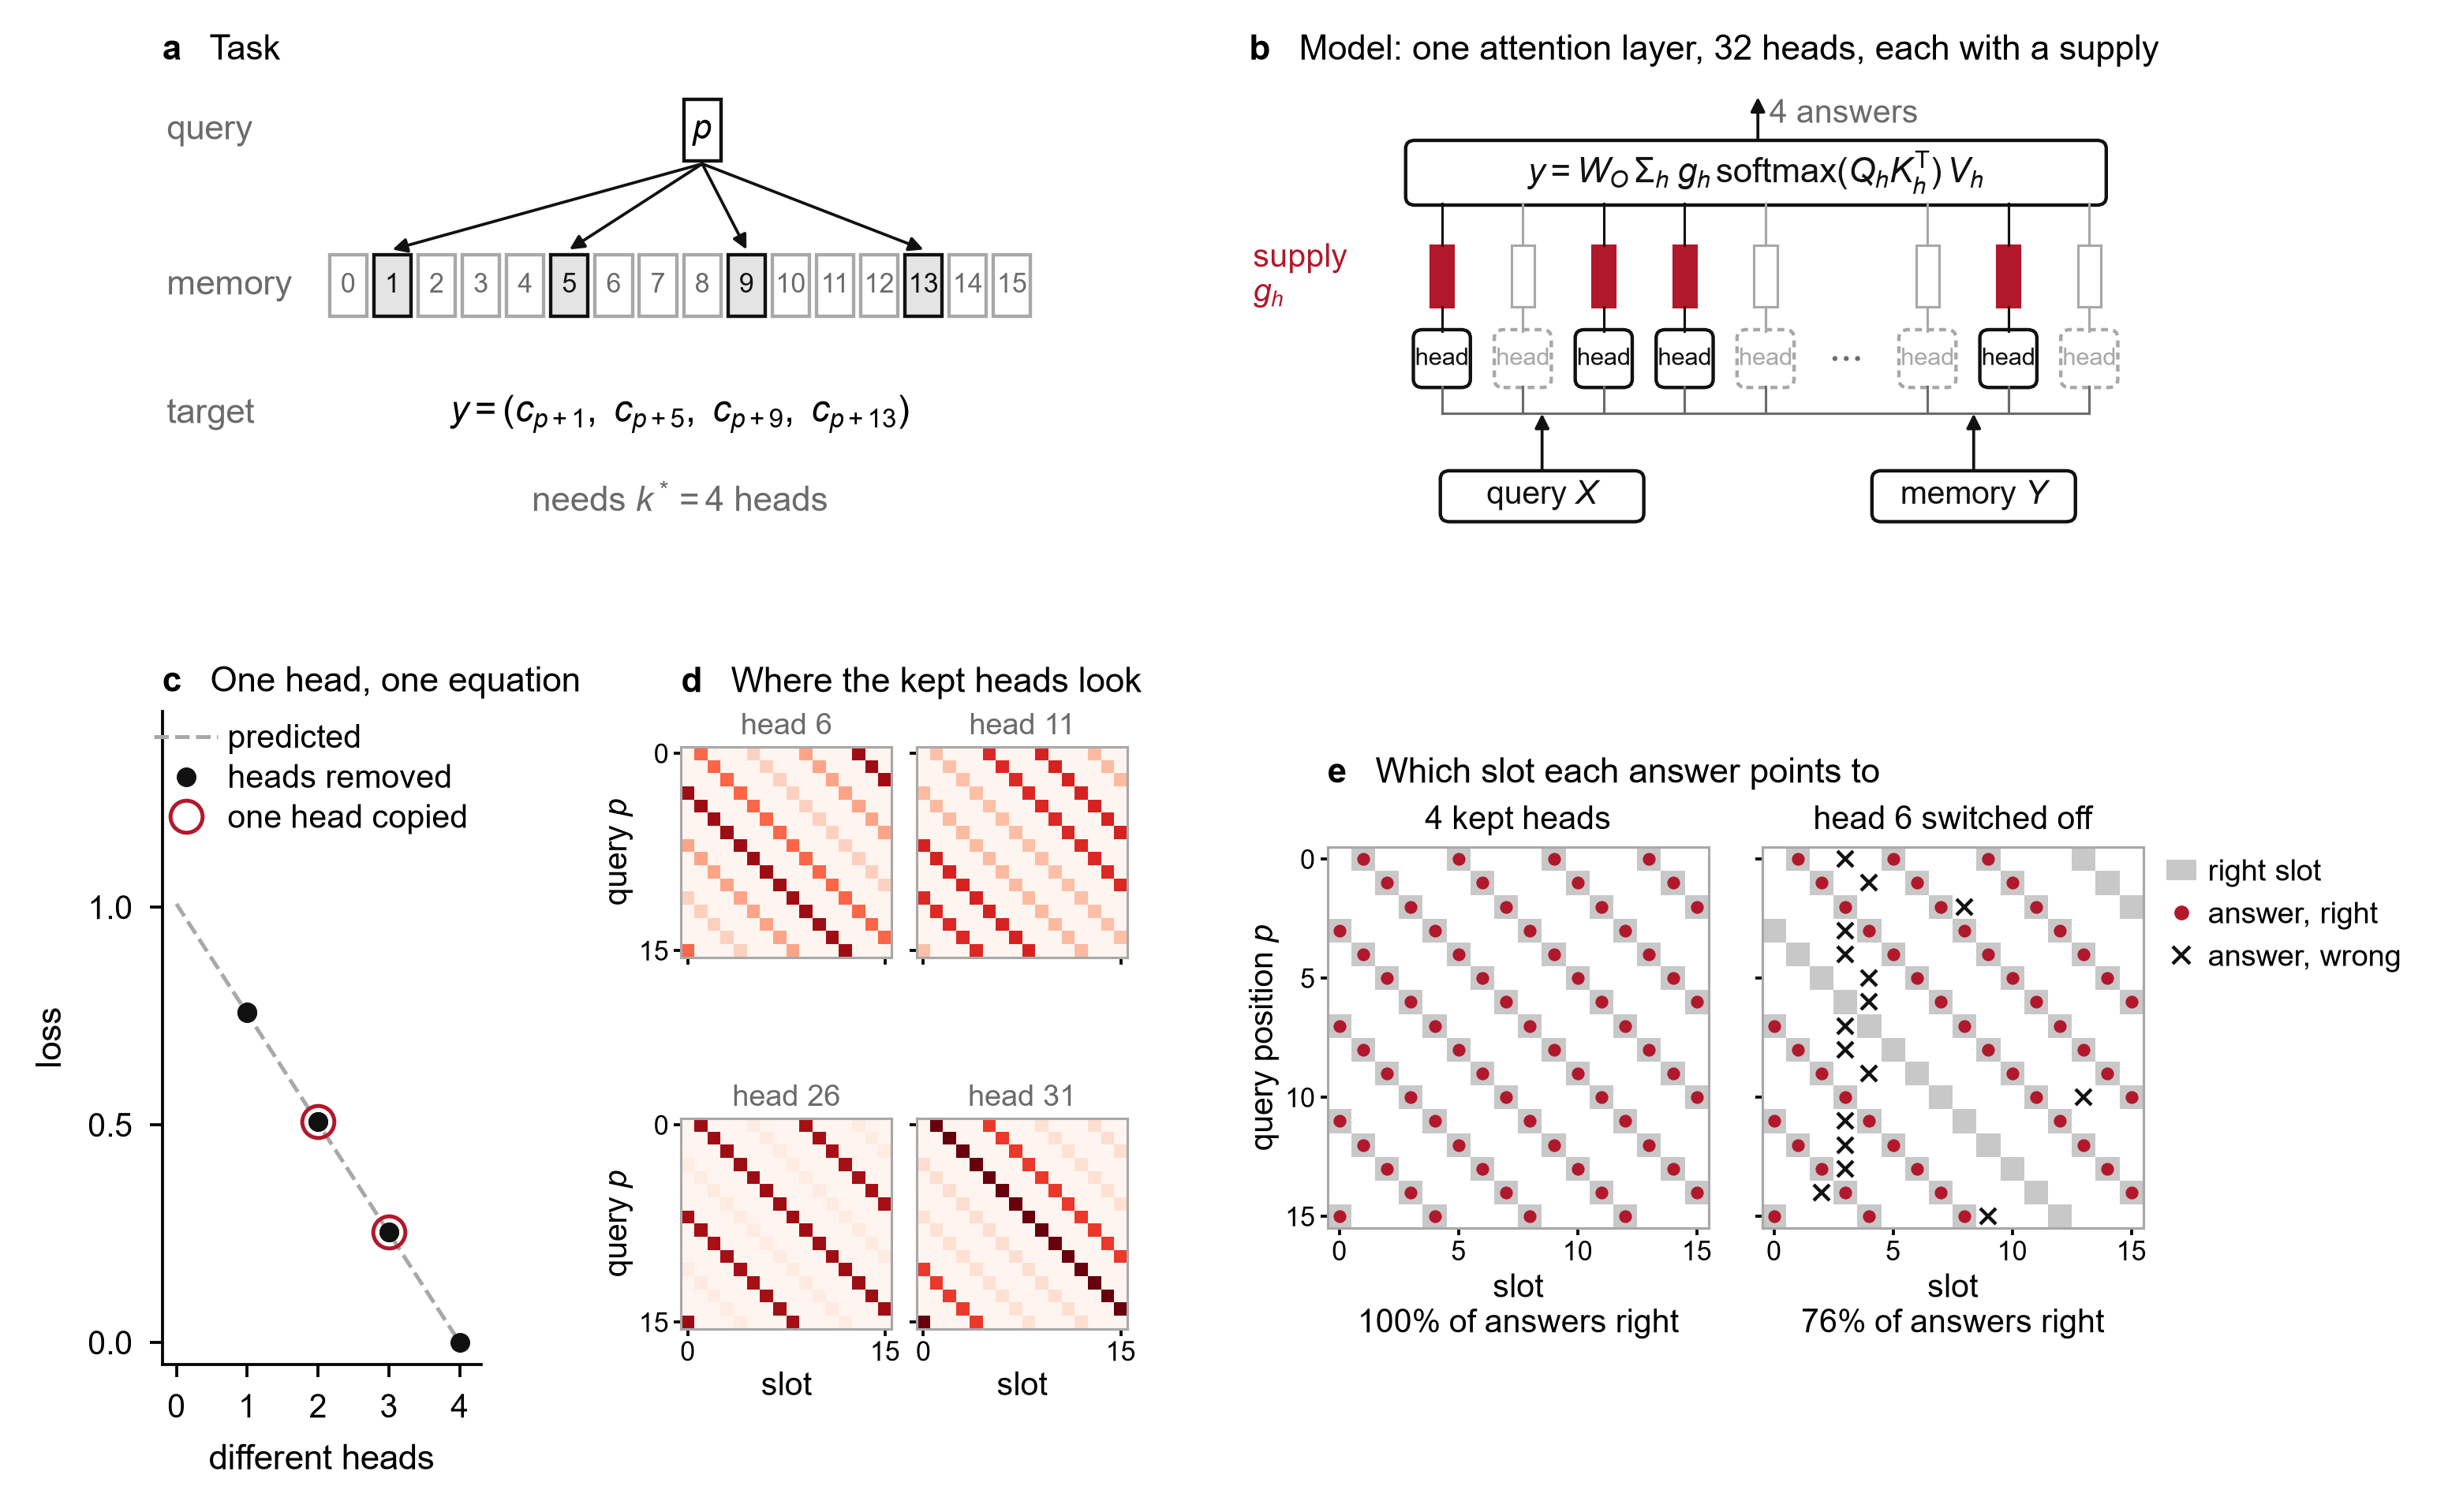

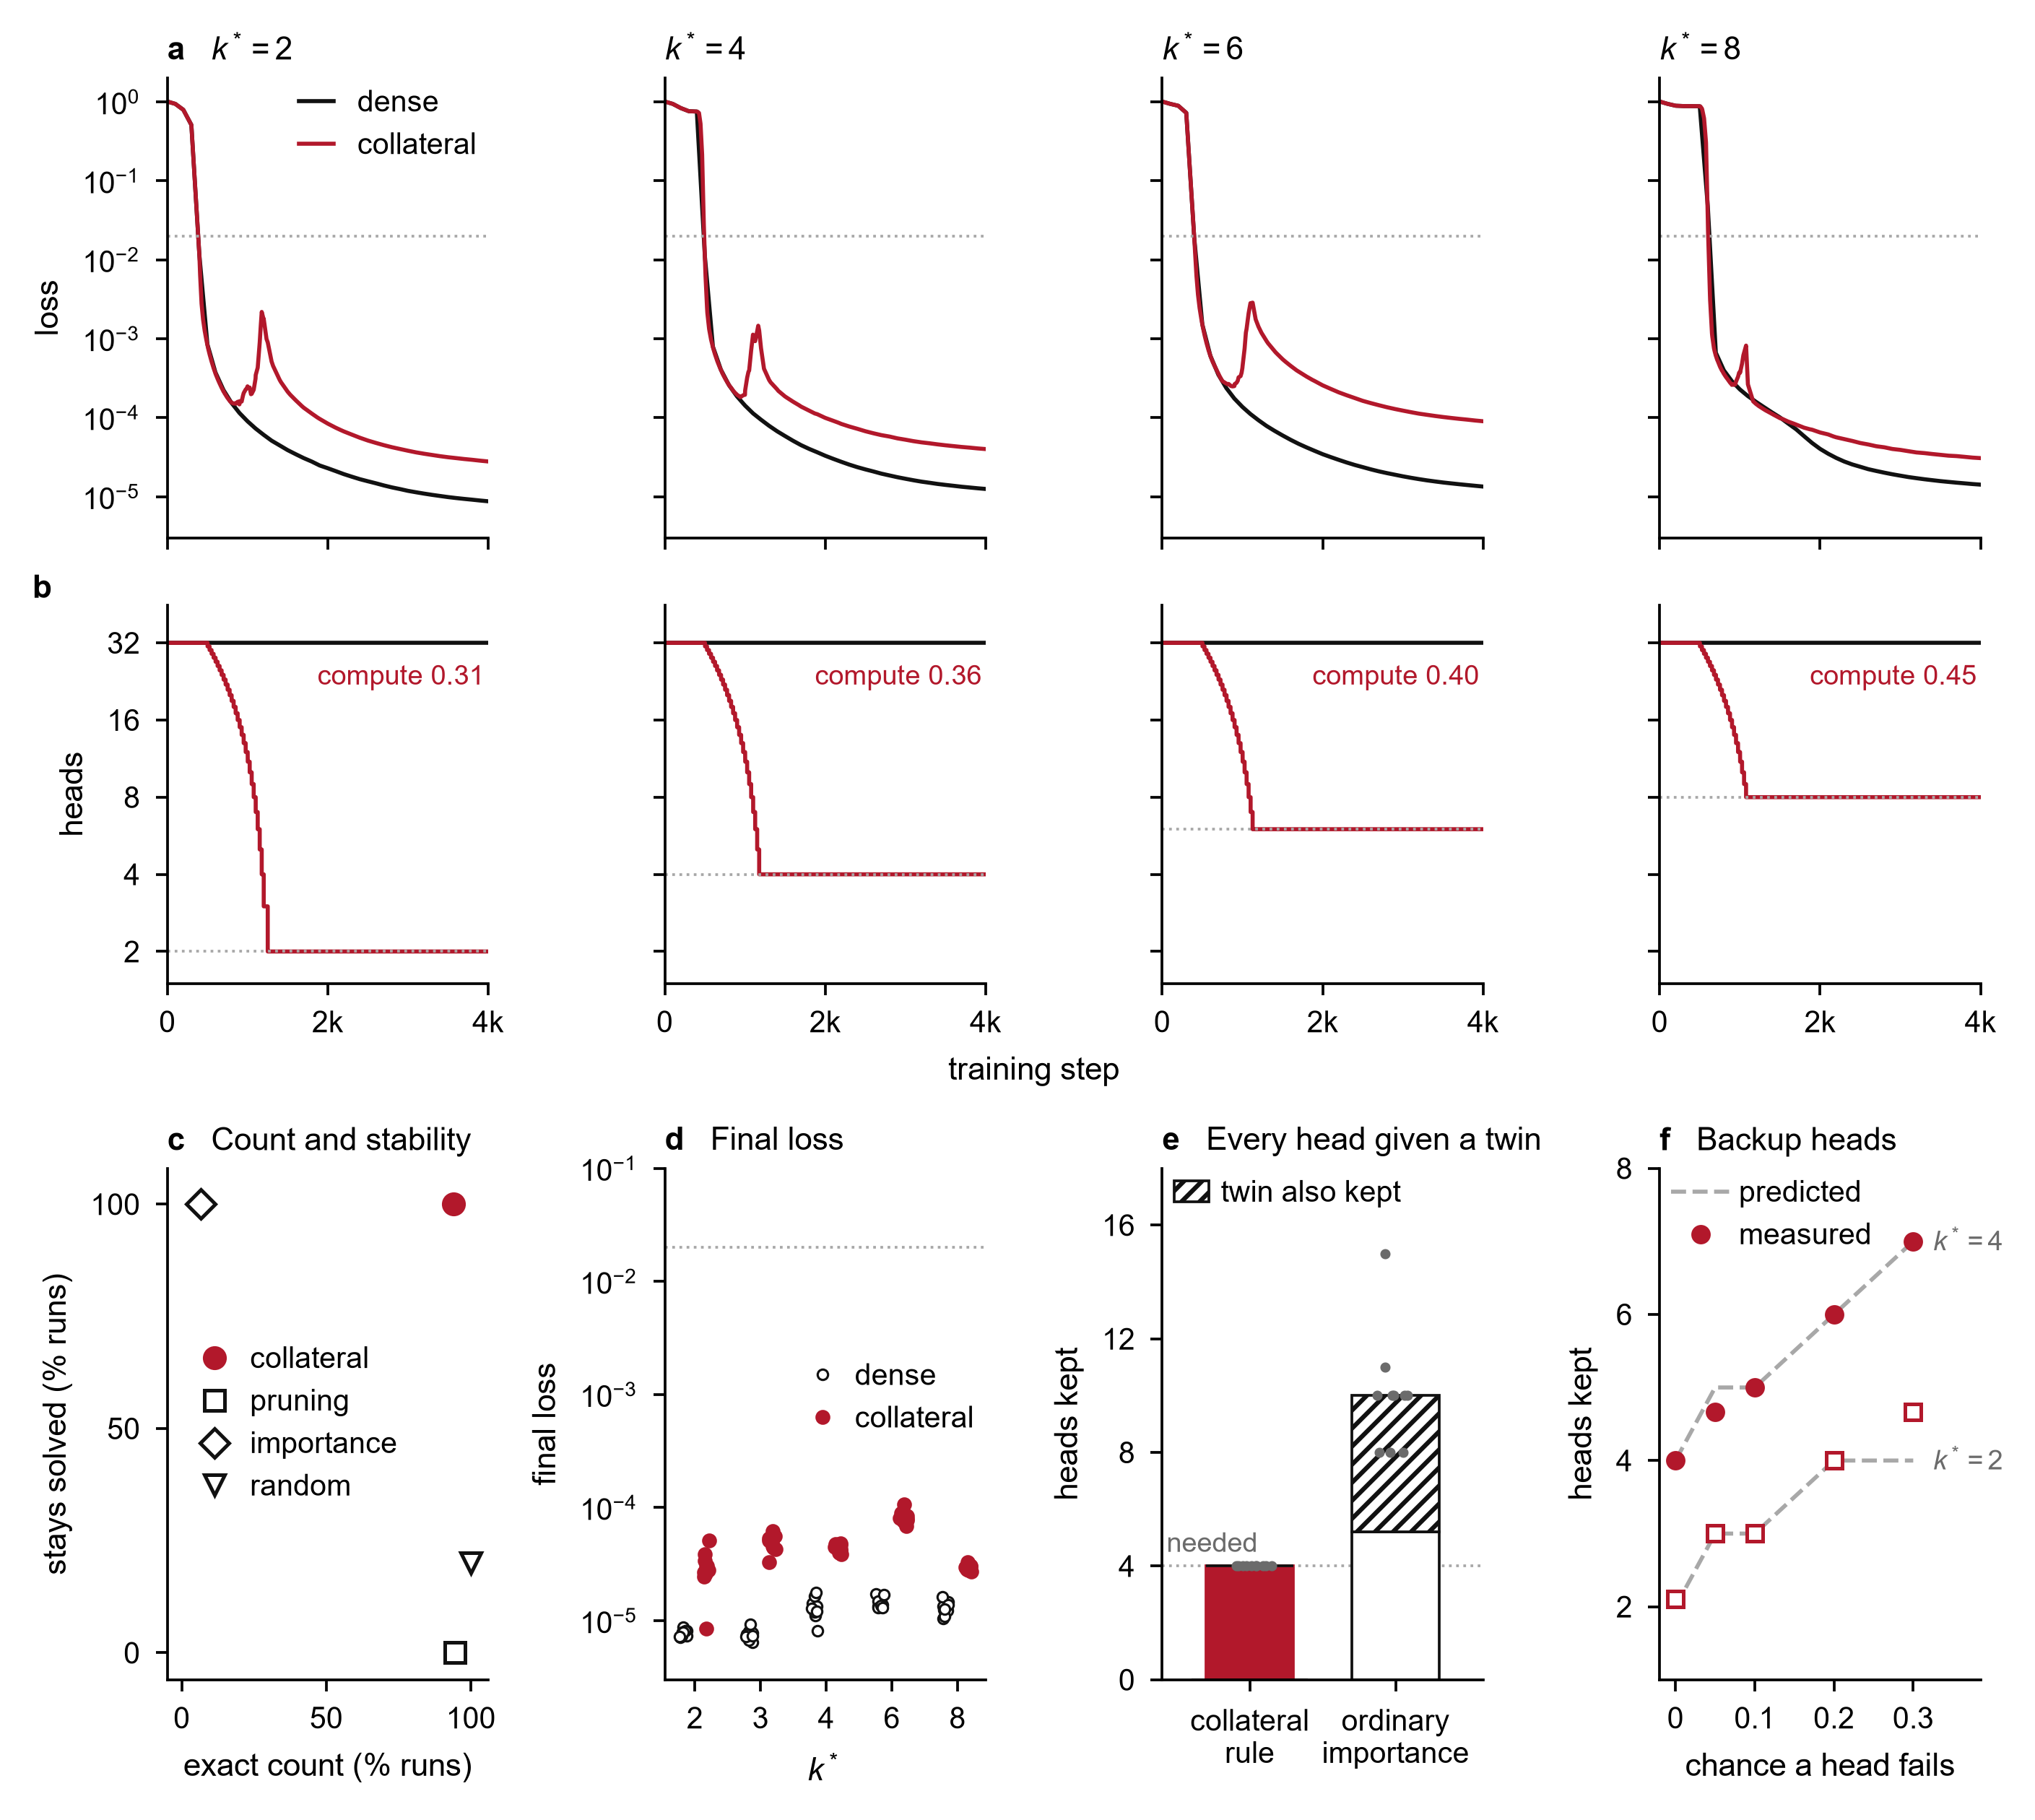

In [16]:
display(Image("../figures/fig_setup.png", width=900))
display(Image("../figures/fig_main.png", width=900))

The figures are made by `experiments/figure_setup.py` and `experiments/figure_main.py` from the same
saved runs; the controls in the paper (one-shot pruning, near-copies) by `experiments/review_analysis.py`.